# Ausgrid monthly data: preparation and seasonal baseline

**Work package 1.** This notebook reads the monthly data from `ausgrid-synthetic/data/raw/monthly/`, prepares solar and non-solar monthly records, assigns household-level train/validation/test splits, runs a seasonal-resampling benchmark, and saves metrics and plots. It does not train a VAE or diffusion model.

Run all cells in Colab or locally. Put either the original ZIP or its three extracted files under `ausgrid-synthetic/data/raw/monthly/` in MyDrive (or the local project). In Colab the notebook mounts Drive if needed and accepts both `MyDrive/ausgrid-synthetic/` and `MyDrive/ausgrid-synthetic/ausgrid-synthetic/` project layouts. It creates `monthly_work_package_1/` in the resolved project root without modifying raw data. Requires pandas, NumPy, SciPy, Matplotlib, and openpyxl.


In [14]:
from __future__ import annotations
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wasserstein_distance

BASE = {"SC", "PK", "LVP", "SH", "LVS", "OP"}
CONTROLLED = {"OP1", "OP2"}
GENERATION = {"PGR", "SGR", "OGR", "OGG", "PGG", "SGG"}
MONTHS = pd.date_range("2007-01-01", "2014-12-01", freq="MS")
BASELINE_YEARS = (2012, 2013, 2014)
SEEDS = (11, 23, 37)


## 1. Prepare household-month channels

Consumption channels keep base tariffs and controlled load separate. Gross PV generation is never subtracted from billed consumption. Repeated site/month/tariff rows are summed; materially negative entries are flagged; missing gross-generation records in solar homes remain missing. Monthly records were **allocated from quarterly bills**, so they are not independent direct meter measurements.


In [15]:
def read_cohort(archive: zipfile.ZipFile, name: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    solar = name == "solar"
    filename = "SolarMonthlyData_2657Custs.csv" if solar else "NonSolarMonthlyData_4064Custs.csv"
    sheet = "SolarSiteAttributes" if solar else "NonSolarSiteAttributes"
    raw = pd.read_csv(archive.open(filename), dtype={"Consumption Month": str})
    raw["month"] = pd.to_datetime(raw["Consumption Month"], format="%m.%Y", errors="raise")
    attr = pd.read_excel(archive.open("Solar Monthly Data Notes.xlsx"), sheet_name=sheet)
    attr = attr.rename(columns={"Customer ID": "customer_id", "Generator Capacity": "capacity_kw", "Postcode": "postcode", "LGA": "lga"})
    attr["postcode"] = attr["postcode"].astype("string")
    if not solar:
        attr["capacity_kw"] = np.nan
    assert attr.customer_id.is_unique and set(attr.customer_id) == set(raw["Customer ID"])

    period = raw[raw.month.isin(MONTHS)].copy()
    period["material_negative"] = (period["Unit of me"] == "KWH") & (period.Sum < -0.01)
    duplicated = int(period.duplicated(["Customer ID", "month", "Netwk Bill Rate Type", "Unit of me"]).sum())
    all_codes = set(period["Netwk Bill Rate Type"])
    assert all_codes <= BASE | CONTROLLED | GENERATION
    kwh = period[period["Unit of me"] == "KWH"].copy()
    # Remove roundoff-sized negative numbers while retaining material negative
    # entries in the output for auditing and excluding them from model fitting.
    kwh["value"] = kwh.Sum.mask((kwh.Sum < 0) & (kwh.Sum >= -0.01), 0)
    kwh["channel"] = np.select(
        [kwh["Netwk Bill Rate Type"].isin(BASE),
         kwh["Netwk Bill Rate Type"].isin(CONTROLLED),
         kwh["Netwk Bill Rate Type"].isin(GENERATION)],
        ["base_kwh", "controlled_kwh", "generation_kwh"], default="unknown",
    )
    grouped = kwh.groupby(["Customer ID", "month", "channel"], observed=True).value.sum().unstack("channel")
    for channel in ("base_kwh", "controlled_kwh", "generation_kwh"):
        if channel not in grouped:
            grouped[channel] = np.nan
    grouped = grouped.reset_index().rename(columns={"Customer ID": "customer_id"})
    days = (period[period["Unit of me"] == "DAY"]
            .groupby(["Customer ID", "month"]).Sum.sum()
            .rename("billed_days").reset_index()
            .rename(columns={"Customer ID": "customer_id"}))
    neg = (period.groupby(["Customer ID", "month"]).material_negative.any()
           .rename("material_negative").reset_index()
           .rename(columns={"Customer ID": "customer_id"}))

    grid = pd.MultiIndex.from_product([attr.customer_id, MONTHS], names=["customer_id", "month"]).to_frame(index=False)
    panel = grid.merge(attr, on="customer_id", how="left", validate="many_to_one")
    panel = panel.merge(grouped, on=["customer_id", "month"], how="left", validate="one_to_one")
    panel = panel.merge(days, on=["customer_id", "month"], how="left", validate="one_to_one")
    panel = panel.merge(neg, on=["customer_id", "month"], how="left", validate="one_to_one")
    panel["material_negative"] = panel.material_negative.astype("boolean").fillna(False).astype(bool)
    panel["controlled_kwh"] = panel.controlled_kwh.fillna(0)
    if not solar:
        panel["generation_kwh"] = 0.0  # Structural zero for non-solar sites.
    panel["cohort"] = name
    panel["household_id"] = name + "_" + panel.customer_id.astype(str)
    panel["year"] = panel.month.dt.year
    panel["month_number"] = panel.month.dt.month
    panel["calendar_days"] = panel.month.dt.days_in_month
    panel["complete_billed_days"] = np.isclose(panel.billed_days, panel.calendar_days, atol=1e-5)
    panel["has_generation_record"] = panel.generation_kwh.notna() if solar else False
    panel["total_consumption_kwh"] = panel.base_kwh + panel.controlled_kwh
    panel["usable_month"] = (
        panel.complete_billed_days & panel.base_kwh.notna() &
        panel.generation_kwh.notna() & ~panel.material_negative &
        (panel.base_kwh >= 0) & (panel.controlled_kwh >= 0) &
        (panel.generation_kwh >= 0)
    )
    qa = {
        "input_rows_all_dates": len(raw), "rows_2007_2014": len(period),
        "customers": len(attr), "raw_months": raw.month.nunique(),
        "raw_first_month": str(raw.month.min().date()), "raw_last_month": str(raw.month.max().date()),
        "repeated_site_month_tariff_unit_rows": duplicated,
        "material_negative_kwh_rows": int(period.material_negative.sum()),
        "households_with_96_primary_day_records": int(panel.groupby("household_id").billed_days.count().eq(96).sum()),
        "months_missing_primary_days": int(panel.billed_days.isna().sum()),
        "months_primary_days_not_calendar": int((panel.billed_days.notna() & ~panel.complete_billed_days).sum()),
        "months_missing_base_kwh": int(panel.base_kwh.isna().sum()),
        "months_missing_generation_records": int(panel.generation_kwh.isna().sum()) if solar else 0,
        "usable_months": int(panel.usable_month.sum()),
    }
    return panel, attr, qa


## 2. Assign household-level splits

Split by household, preserving the 204 solar IDs shared with the earlier half-hour release. The 2012–2014 benchmark requires 36 usable months; a separate 2011–2013 coverage file identifies viable households for the later cross-resolution experiment.


In [16]:
def make_splits(panel: pd.DataFrame, seed: int = 20260928) -> pd.DataFrame:
    sites = panel.drop_duplicates("household_id")[
        ["household_id", "customer_id", "cohort", "lga", "postcode", "capacity_kw"]].copy()
    sites["overlap_interval"] = (sites.cohort == "solar") & (sites.customer_id <= 300)
    assert sites.overlap_interval.sum() == 204
    rng = np.random.default_rng(seed)
    sites["split"] = ""
    # Protect the scarce overlap sample while approximately balancing PV size.
    solar_capacity = sites.loc[sites.cohort == "solar", "capacity_kw"]
    cut = solar_capacity.quantile([1 / 3, 2 / 3]).to_numpy()
    sites["cap_band"] = np.searchsorted(cut, sites.capacity_kw.fillna(0), side="right")
    sites["stratum"] = np.where(
        sites.cohort == "non-solar", "non-solar",
        np.where(sites.overlap_interval, "overlap_", "other_solar_") + sites.cap_band.astype(str),
    )
    for _, grp in sites.groupby("stratum", sort=True):
        loc = rng.permutation(grp.index.to_numpy())
        ntrain = int(round(0.70 * len(loc)))
        nval = int(round(0.15 * len(loc)))
        sites.loc[loc[:ntrain], "split"] = "train"
        sites.loc[loc[ntrain:ntrain + nval], "split"] = "validation"
        sites.loc[loc[ntrain + nval:], "split"] = "test"
    assert (sites.split != "").all() and sites.household_id.is_unique
    return sites.drop(columns=["cap_band", "stratum"])


def eligible_sites(panel: pd.DataFrame) -> pd.Index:
    sub = panel[panel.year.isin(BASELINE_YEARS)]
    counts = sub.groupby("household_id").usable_month.sum()
    return counts[counts == 36].index


## 3. Seasonal-resampling benchmark

Use **training households only** as donors. Prefer a household in the same LGA and with nearby PV capacity; keep its three-year shape, apply annual scale noise, and scale gross generation by target-to-donor PV capacity. This is a benchmark, **not a privacy-safe release**: the normalized donor profile shape remains recognizable.


In [17]:
def generate_baseline(panel: pd.DataFrame, splits: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    eligible = set(eligible_sites(panel))
    sites = splits[splits.household_id.isin(eligible)]
    donors = sites[sites.split == "train"].copy()
    targets = sites[sites.split == "test"].copy()
    history = panel[(panel.household_id.isin(eligible)) & panel.year.isin(BASELINE_YEARS)]
    by_id = {key: grp.sort_values("month") for key, grp in history.groupby("household_id", sort=False)}
    rows = []
    fallback = {"lga_and_capacity": 0, "capacity_only": 0, "lga_only": 0, "cohort_only": 0}
    for target_number, target in enumerate(targets.itertuples(index=False), start=1):
        candidate = donors[donors.cohort == target.cohort]
        in_lga = candidate.lga.eq(target.lga)
        if target.cohort == "solar":
            near_capacity = (candidate.capacity_kw - target.capacity_kw).abs() <= 0.75
            choices = [(in_lga & near_capacity, "lga_and_capacity"),
                       (near_capacity, "capacity_only"),
                       (in_lga, "lga_only")]
        else:
            choices = [(in_lga, "lga_only")]
        selected, mode = candidate, "cohort_only"
        for mask, label in choices:
            if int(mask.sum()) >= 10:
                selected, mode = candidate[mask], label
                break
        fallback[mode] += 1
        picked = selected.iloc[rng.integers(len(selected))]
        original = by_id[picked.household_id]
        cons_noise = rng.lognormal(mean=-0.5 * 0.08**2, sigma=0.08, size=3)
        gen_noise = rng.lognormal(mean=-0.5 * 0.08**2, sigma=0.08, size=3)
        frame = original[["month", "year", "month_number", "base_kwh", "controlled_kwh", "generation_kwh"]].copy()
        year_idx = frame.year.to_numpy() - BASELINE_YEARS[0]
        frame["base_kwh"] *= cons_noise[year_idx]
        frame["controlled_kwh"] *= cons_noise[year_idx]
        if target.cohort == "solar":
            frame["generation_kwh"] *= (target.capacity_kw / picked.capacity_kw) * gen_noise[year_idx]
        frame["total_consumption_kwh"] = frame.base_kwh + frame.controlled_kwh
        frame["synthetic_id"] = f"synthetic_{seed}_{target_number:04d}"
        frame["household_id"] = target.household_id  # Evaluation pairing only.
        frame["cohort"] = target.cohort
        frame["lga"] = target.lga
        frame["capacity_kw"] = target.capacity_kw
        rows.append(frame)
    result = pd.concat(rows, ignore_index=True)
    assert result.groupby("household_id").size().eq(36).all()
    return result, {"train_donors": len(donors), "test_targets": len(targets), "selection_modes": fallback}


## 4. Evaluation and plot

Annual Wasserstein-1 compares household-year totals; calendar-month Wasserstein-1 assesses seasonal distributions. The relationship table checks controlled-load prevalence and the PV capacity–generation and consumption–generation correlations. Three seeds measure variation in the resampling benchmark.


In [18]:
def evaluate(panel: pd.DataFrame, synthetic: pd.DataFrame, splits: pd.DataFrame, seed: int) -> list[dict]:
    target_ids = set(synthetic.household_id.unique())
    real = panel[(panel.household_id.isin(target_ids)) & panel.year.isin(BASELINE_YEARS)]
    metric_rows = []
    for cohort in ("solar", "non-solar"):
        r, s = real[real.cohort == cohort], synthetic[synthetic.cohort == cohort]
        for channel in ("total_consumption_kwh", "controlled_kwh", "generation_kwh"):
            if cohort == "non-solar" and channel == "generation_kwh":
                continue
            ra = r.groupby(["household_id", "year"])[channel].sum().to_numpy()
            sa = s.groupby(["household_id", "year"])[channel].sum().to_numpy()
            month_w1 = np.mean([
                wasserstein_distance(r[r.month_number == m][channel], s[s.month_number == m][channel])
                for m in range(1, 13)
            ])
            denom = np.median(ra)
            metric_rows.append({
                "seed": seed, "cohort": cohort, "channel": channel,
                "target_households": r.household_id.nunique(),
                "annual_real_median_kwh": float(np.median(ra)),
                "annual_synthetic_median_kwh": float(np.median(sa)),
                "annual_w1_kwh": float(wasserstein_distance(ra, sa)),
                "annual_w1_over_real_median": float(wasserstein_distance(ra, sa) / denom) if denom > 0 else np.nan,
                "mean_calendar_month_w1_kwh": float(month_w1),
                "zero_month_rate_real": float((r[channel] == 0).mean()),
                "zero_month_rate_synthetic": float((s[channel] == 0).mean()),
            })
    return metric_rows


def evaluate_relationships(panel: pd.DataFrame, synthetic: pd.DataFrame, seed: int) -> list[dict]:
    ids = set(synthetic.household_id)
    real = panel[(panel.household_id.isin(ids)) & (panel.year == 2014)]
    syn = synthetic[synthetic.year == 2014]
    results = []
    for data, kind in ((real, "real"), (syn, "synthetic")):
        for cohort in ("solar", "non-solar"):
            annual = data[data.cohort == cohort].groupby("household_id").agg(
                consumption=("total_consumption_kwh", "sum"),
                controlled=("controlled_kwh", "sum"),
                generation=("generation_kwh", "sum"),
                capacity=("capacity_kw", "first"),
            )
            results.append({
                "seed": seed, "kind": kind, "cohort": cohort,
                "households": len(annual),
                "controlled_load_presence_fraction": float((annual.controlled > 0).mean()),
                "capacity_generation_spearman": float(spearmanr(annual.capacity, annual.generation).statistic) if cohort == "solar" else np.nan,
                "consumption_generation_spearman": float(spearmanr(annual.consumption, annual.generation).statistic) if cohort == "solar" else np.nan,
            })
    return results


def plot_seasonality(panel: pd.DataFrame, synthetic: pd.DataFrame, path: Path) -> None:
    real = panel[(panel.household_id.isin(set(synthetic.household_id))) & (panel.year == 2014)]
    syn = synthetic[synthetic.year == 2014]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
    cases = [("solar", "total_consumption_kwh", "Solar households: consumption"),
             ("solar", "generation_kwh", "Solar households: generation"),
             ("non-solar", "total_consumption_kwh", "Non-solar: consumption")]
    for ax, (cohort, channel, title) in zip(axes, cases):
        for data, label, style in [(real, "Held-out real", "-"), (syn, "Synthetic", "--")]:
            d = data[data.cohort == cohort].groupby("month_number")[channel].median()
            ax.plot(d.index, d.to_numpy(), style, label=label, linewidth=2)
        ax.set_title(title)
        ax.set_xticks([1, 3, 5, 7, 9, 11])
        ax.set_xlabel("Month of 2014")
        ax.set_ylabel("Median kWh per household")
        ax.grid(alpha=0.2)
    axes[0].legend(frameon=False)
    fig.savefig(path, dpi=175)
    plt.close(fig)


## 5. Set paths and run

As in the earlier diffusion notebook, check candidate project roots first. In Colab, mount Drive only if no candidate is available; check both possible MyDrive layouts. Then read only `data/raw/monthly/`, accepting either the three extracted files or their ZIP. Outputs go into the resolved project's `monthly_work_package_1/` folder.


In [19]:
REQUIRED_FILES = {
    "SolarMonthlyData_2657Custs.csv",
    "NonSolarMonthlyData_4064Custs.csv",
    "Solar Monthly Data Notes.xlsx",
}

def has_monthly_data(project_root: Path) -> bool:
    folder = project_root / "data/raw/monthly"
    if not folder.is_dir():
        return False
    if all((folder / name).is_file() for name in REQUIRED_FILES):
        return True
    for path in folder.iterdir():
        if path.is_file() and path.suffix.lower() == ".zip":
            with zipfile.ZipFile(path) as archive:
                if REQUIRED_FILES.issubset(set(archive.namelist())):
                    return True
    return False

workdir = Path.cwd().resolve()
drive_root = Path("/content/drive/MyDrive/ausgrid-synthetic")
candidates = [workdir, workdir.parent, workdir / "ausgrid-synthetic",
              drive_root, drive_root / "ausgrid-synthetic"]
PROJECT_ROOT = next((p for p in candidates if has_monthly_data(p)), None)
if PROJECT_ROOT is None:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise FileNotFoundError(
            "Monthly data not found. Place the project at ausgrid-synthetic/data/raw/monthly "
            "or open this notebook in Colab with the project in MyDrive."
        ) from exc
    drive.mount("/content/drive")
    PROJECT_ROOT = next((p for p in (drive_root, drive_root / "ausgrid-synthetic")
                         if has_monthly_data(p)), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No data/raw/monthly folder found in MyDrive/ausgrid-synthetic "
        "or MyDrive/ausgrid-synthetic/ausgrid-synthetic."
    )
PROJECT_ROOT = PROJECT_ROOT.resolve()
RAW_MONTHLY_DIR = PROJECT_ROOT / "data" / "raw" / "monthly"
extracted = all((RAW_MONTHLY_DIR / name).is_file() for name in REQUIRED_FILES)
DATA_ZIP = None
if not extracted:
    archives = []
    for path in sorted(RAW_MONTHLY_DIR.iterdir()):
        if path.is_file() and path.suffix.lower() == ".zip":
            with zipfile.ZipFile(path) as z:
                if REQUIRED_FILES.issubset(set(z.namelist())):
                    archives.append(path)
    if len(archives) != 1:
        raise FileNotFoundError(
            f"Expected the three extracted monthly files or exactly one matching ZIP in {RAW_MONTHLY_DIR}; found {len(archives)} matching ZIPs."
        )
    DATA_ZIP = archives[0]

class FolderSource:
    def __init__(self, folder: Path):
        self.folder = folder
    def __enter__(self):
        return self
    def __exit__(self, *exc):
        return False
    def open(self, name: str):
        if name not in REQUIRED_FILES:
            raise KeyError(name)
        return (self.folder / name).open("rb")

def open_monthly_source():
    return zipfile.ZipFile(DATA_ZIP) if DATA_ZIP is not None else FolderSource(RAW_MONTHLY_DIR)

OUTPUT_DIR = PROJECT_ROOT / "monthly_work_package_1"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Input:", DATA_ZIP if DATA_ZIP is not None else RAW_MONTHLY_DIR)
print("Outputs:", OUTPUT_DIR)


Input: /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/data/raw/monthly
Outputs: /content/drive/MyDrive/ausgrid-synthetic/ausgrid-synthetic/monthly_work_package_1


In [20]:
with open_monthly_source() as archive:
    solar, _, qs = read_cohort(archive, "solar")
    nonsolar, _, qn = read_cohort(archive, "non-solar")
panel = pd.concat([solar, nonsolar], ignore_index=True).sort_values(["cohort", "customer_id", "month"])
splits = make_splits(panel)
panel = panel.merge(splits[["household_id", "split", "overlap_interval"]], on="household_id", validate="many_to_one")
eligible = set(eligible_sites(panel))
splits["eligible_2012_2014"] = splits.household_id.isin(eligible)
overlap_coverage = (panel[panel.overlap_interval & panel.year.between(2011, 2013)]
                    .groupby(["household_id", "split"], as_index=False)
                    .agg(usable_months_2011_2013=("usable_month", "sum")))
overlap_coverage["complete_36_months"] = overlap_coverage.usable_months_2011_2013.eq(36)
assert len(panel) == (2657 + 4064) * 96
assert not panel.duplicated(["household_id", "month"]).any()
panel.to_csv(OUTPUT_DIR / "monthly_panel_2007_2014.csv.gz", index=False, compression="gzip")
splits.to_csv(OUTPUT_DIR / "household_splits.csv", index=False)
overlap_coverage.to_csv(OUTPUT_DIR / "overlap_coverage_2011_2013.csv", index=False)
print("Panel rows:", len(panel))
print("Complete 2011–2013 overlap by split:", overlap_coverage[overlap_coverage.complete_36_months].split.value_counts().to_dict())


Panel rows: 645216
Complete 2011–2013 overlap by split: {'train': 113, 'test': 24, 'validation': 19}


In [21]:
metrics, relationships, baseline_info = [], [], {}
for seed in SEEDS:
    synthetic, info = generate_baseline(panel, splits, seed)
    metrics.extend(evaluate(panel, synthetic, splits, seed))
    relationships.extend(evaluate_relationships(panel, synthetic, seed))
    baseline_info[str(seed)] = info
    if seed == SEEDS[0]:
        synthetic.drop(columns="household_id").to_csv(
            OUTPUT_DIR / "baseline_synthetic_2012_2014_seed11.csv.gz", index=False, compression="gzip")
        plot_seasonality(panel, synthetic, OUTPUT_DIR / "baseline_seasonality_2014.png")
metric_table = pd.DataFrame(metrics)
relationship_table = pd.DataFrame(relationships)
metric_table.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)
relationship_table.to_csv(OUTPUT_DIR / "baseline_relationship_metrics.csv", index=False)
audit = {"source": str(DATA_ZIP.name if DATA_ZIP is not None else RAW_MONTHLY_DIR.relative_to(PROJECT_ROOT)), "panel_range": "2007-01 through 2014-12",
         "baseline_range": "2012-01 through 2014-12", "split_seed": 20260928,
         "baseline_seeds": SEEDS, "cohorts": {"solar": qs, "non-solar": qn},
         "split_counts": splits.groupby(["cohort", "split"]).size().unstack(fill_value=0).to_dict("index"),
         "interval_overlap_counts": splits[splits.overlap_interval].split.value_counts().to_dict(),
         "overlap_complete_2011_2013_by_split": overlap_coverage[overlap_coverage.complete_36_months].split.value_counts().to_dict(),
         "overlap_complete_2012_2014": int(splits[splits.overlap_interval].eligible_2012_2014.sum()),
         "eligible_counts": splits[splits.eligible_2012_2014].groupby(["cohort", "split"]).size().unstack(fill_value=0).to_dict("index"),
         "baseline": baseline_info}
(OUTPUT_DIR / "quality_report.json").write_text(json.dumps(audit, indent=2) + "\n")
print("Baseline targets:", baseline_info[str(SEEDS[0])]["test_targets"])
print(metric_table.groupby(["cohort", "channel"])[["annual_w1_kwh", "annual_w1_over_real_median"]].mean().round(3).to_string())


Baseline targets: 969
                                 annual_w1_kwh  annual_w1_over_real_median
cohort    channel                                                         
non-solar controlled_kwh               106.728                         NaN
          total_consumption_kwh        260.217                       0.041
solar     controlled_kwh               104.570                         NaN
          generation_kwh                95.594                       0.044
          total_consumption_kwh        854.449                       0.129


## 6. Reconcile and inspect

These checks confirm row uniqueness, no household overlap between splits, the overlap coverage count, 36-month synthetic trajectories, and annual source-to-panel energy totals. The plot shows the 2014 median monthly trajectories for the first resampling seed.


PASS: panel, splits, overlap coverage, synthetic length, and source totals


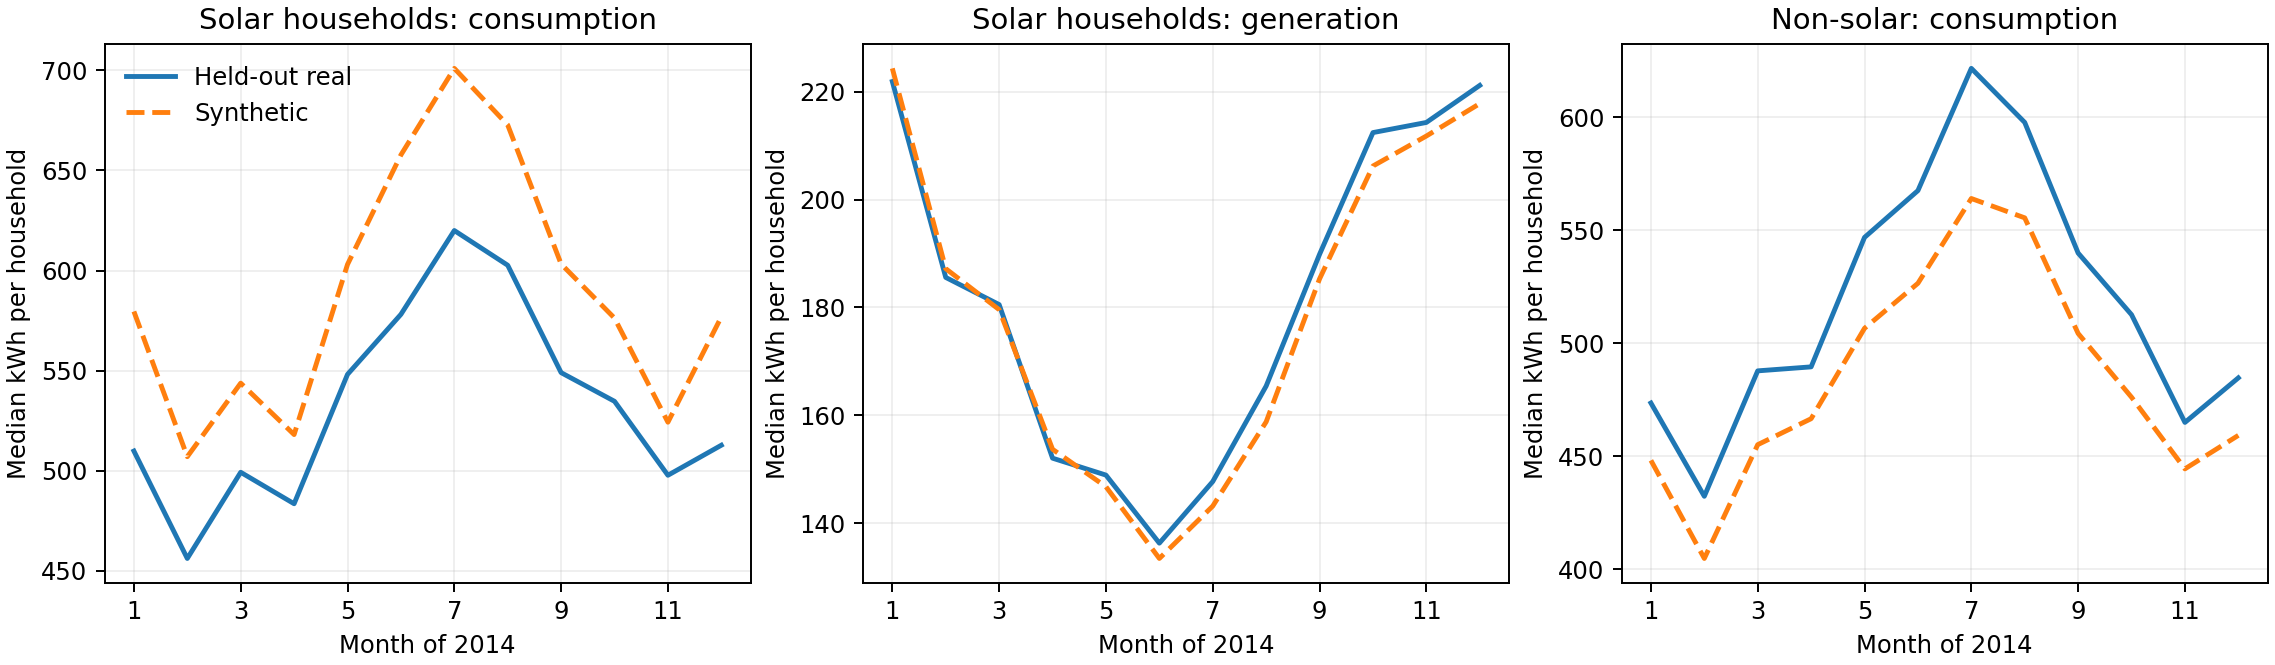

In [22]:
assert splits.household_id.is_unique and len(splits) == 6721
assert splits.overlap_interval.sum() == 204
assert overlap_coverage.complete_36_months.sum() == 156
assert baseline_info[str(SEEDS[0])]["test_targets"] == 969
assert synthetic.groupby("household_id").size().eq(36).all()
with open_monthly_source() as archive:
    for cohort, filename in (("solar", "SolarMonthlyData_2657Custs.csv"),
                             ("non-solar", "NonSolarMonthlyData_4064Custs.csv")):
        raw = pd.read_csv(archive.open(filename), dtype={"Consumption Month": str})
        raw = raw[(raw["Unit of me"] == "KWH") & raw["Consumption Month"].str.endswith(".2012")].copy()
        raw["adjusted"] = raw.Sum.mask((raw.Sum < 0) & (raw.Sum >= -0.01), 0)
        sub = panel[(panel.cohort == cohort) & (panel.year == 2012)]
        for channel, codes in (("base_kwh", BASE), ("controlled_kwh", CONTROLLED), ("generation_kwh", GENERATION)):
            original = raw.loc[raw["Netwk Bill Rate Type"].isin(codes), "adjusted"].sum()
            prepared = sub[channel].sum()
            assert np.isclose(original, prepared, atol=0.01), (cohort, channel)
print("PASS: panel, splits, overlap coverage, synthetic length, and source totals")
from IPython.display import display, Image
display(Image(filename=str(OUTPUT_DIR / "baseline_seasonality_2014.png")))


### Result and next experiment

The three-seed average annual W1, normalized by the real annual median, is approximately **12.9%** for solar household consumption, **4.1%** for non-solar consumption, and **4.4%** for gross generation. The first seed visibly overestimates solar household consumption. None of the linked half-hour households has all 36 usable 2012–2014 months; **156** do in 2011–2013, of which **24** are held out for testing.

Next: train a conditional monthly VAE on the **same eligible training households** and compare its distribution, seasonal and relationship scores with this benchmark. For any proposed synthetic release, repeat the household privacy attack: this baseline directly resamples training shapes.
